# candidate vocalization classification as Noise or Vocal demo
~
### run this notebook to see a demonstration of the Noise/Vocal Convolutional Neural Network classification process
~
#### what will happen:
#### necessary packages are loaded
#### create an instance of the NoiseClassifier
#### run the classifier in the provided example (or you can change the path to run one of your own audios)
#### visualization of some candidate vocalizations and their classifications
~
#### requirements:
#### keep VocalPy's original directory structure
#### run this notebook from inside the _notebook_ directory
#### have the example_outputs directory inside the _audio_ directory (comes with VocalPy by default)

In [1]:
import os
import sys
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

import torch

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torch.autograd import Variable
from classes.classifier import VocalClassifier

In [2]:
path_to_spectrogram = os.path.join('..', 'audios','example_outputs','spectrogram')
NoiseClassifier = VocalClassifier(type='noise', path_to_spectrograms=path_to_spectrogram, batch_size=1)
NoiseClassifier.model.eval()
dataiter = iter(NoiseClassifier.dataloader)

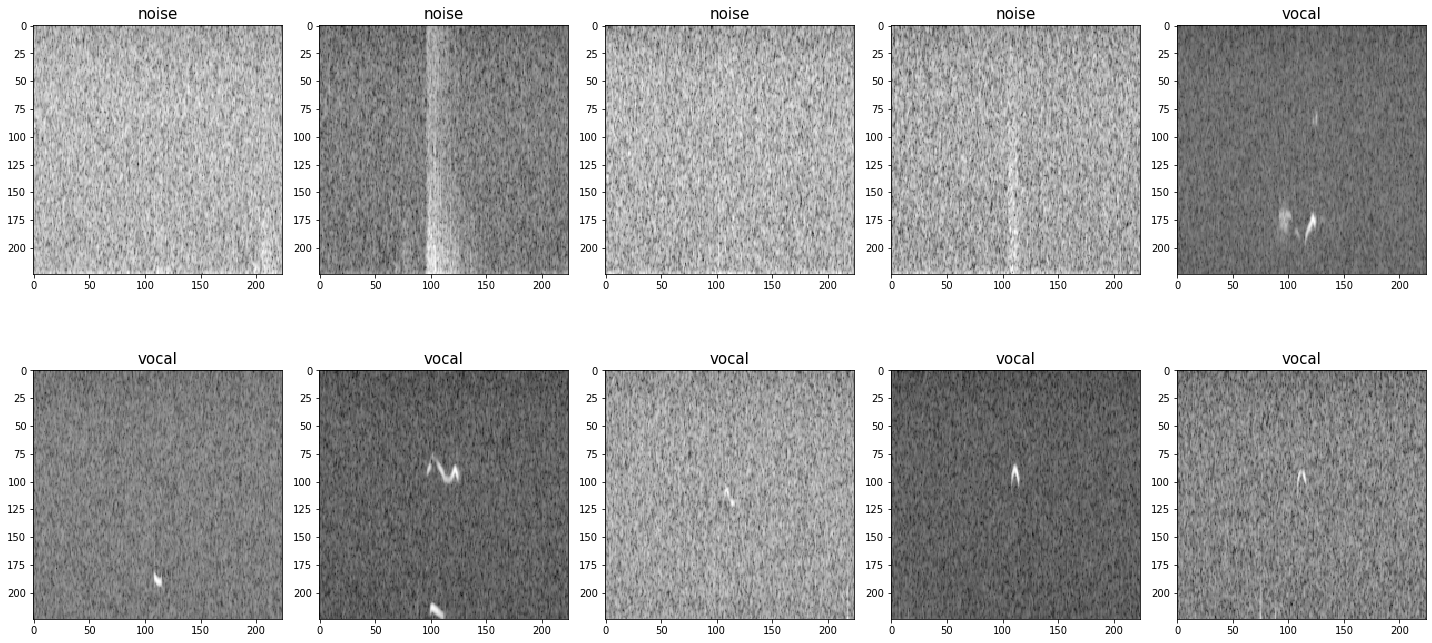

In [3]:
fig, axs = plt.subplots(2, 5, figsize=(20, 10))
for ax in axs.reshape(-1):
    image = dataiter.next()
    image = image.to(NoiseClassifier.device)
    image = Variable(image)
    score = NoiseClassifier.model(image)
    _, predicted = torch.max(score.data, 1)
    ax.imshow(image.cpu().numpy()[0,0,:,:], cmap='gray')
    title = NoiseClassifier.classes[predicted.numpy()[0]]
    ax.set_title(title, size=15)

fig.tight_layout()
plt.show()